In [2]:
import pandas as pd
import numpy as np


Step 2

In [ ]:
# 2.1
df = pd.read_excel('credit_dataset.xls', header=1)
print(df.shape[0])

30000


In [ ]:
# 2.2
print(df.shape[1]-1)

# answer is 24 excluding outcome

24


2.3

Sex - Equal Credit Opportunity Act (ECOA) / Regulation B; also Title VII framing for sex discrimination
Age - ECOA (age is a prohibited basis in credit); ADEA is the usual employment-age statute if you want a parallel
Marriage ( Marital status) - ECOA (marital status is an explicit prohibited basis; FAQ allows it here)



Step 3

3.1 

Dataset outcome = Y

In [14]:
# 3.2 Creditworthiness formula
# Start at 100; deduct 10 points per month of delay across PAY_0, PAY_2..PAY_6.
# Only positive PAY values count as delay (-2, -1, 0 do not). Clip at 0.
# score = max(0, 100 - 10 * sum(max(PAY_i, 0)))

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
delay_months = df[pay_cols].clip(lower=0).sum(axis=1)
df['creditworthiness'] = (100 - 10 * delay_months).clip(lower=0)

# sanity check: ID 1 should be 60 (delays 2+2=4 → 100-40)
print(df.loc[df['ID'] == 1, ['ID'] + pay_cols + ['creditworthiness']])
print(df['creditworthiness'].describe())

   ID  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  creditworthiness
0   1      2      2     -1     -1     -2     -2                60
count    30000.000000
mean        85.055667
std         28.064981
min          0.000000
25%         80.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: creditworthiness, dtype: float64


3.3

protected class attribute = age

3.4 

Unprivileged: older (age ≥ 40)
Privileged: younger (age < 40)

In [15]:
# 3.5
train_df = df.sample(frac=0.5, random_state=42)
# drop the target for test data
test_df = df.drop(train_df.index)

# Report privileged/unprivileged counts in train and test.
for name, split in [('train', train_df), ('test', test_df)]:
    priv = (split['AGE'] < 40).sum()
    unpriv = (split['AGE'] >= 40).sum()
    print(f'{name}: privileged (young)={priv}, unprivileged (old)={unpriv}, n={len(split)}')

train: privileged (young)=10467, unprivileged (old)=4533, n=15000
test: privileged (young)=10389, unprivileged (old)=4611, n=15000


Step 4

* This is where i implement the 65 threshold.

<Axes: >

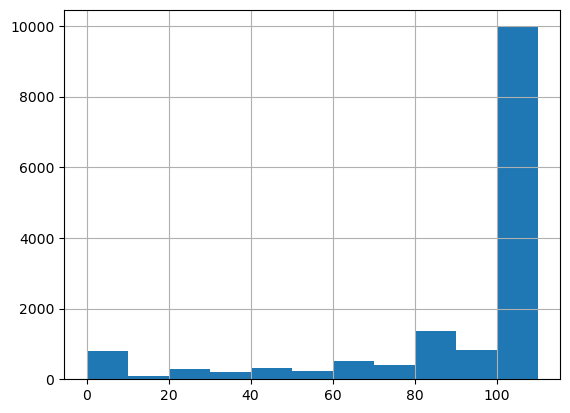

In [ ]:
# 4.1
#  There is 15000 customers in the training data
train_df['creditworthiness'].hist(bins=range(0, 111, 10))

In [18]:
# 4.2

y = train_df['default payment next month']  # 0=approved(good), 1=denied(bad)
score = train_df['creditworthiness']

def profit_for_threshold(x):
    approve = score >= x
    true_approve = (y == 0)
    p = np.where(true_approve & approve, 10,
        np.where(true_approve & ~approve, -5,
        np.where(~true_approve & approve, -10, 0)))
    return p.sum()

thresholds = range(10, 101, 5) #from score 10 too 100 with increament of 5
profits = {x: profit_for_threshold(x) for x in thresholds}
best_x = max(profits, key=profits.get)
print(profits)
print('best threshold', best_x, 'max profit', profits[best_x])

{10: 86190, 15: 86020, 20: 86020, 25: 86335, 30: 86335, 35: 85600, 40: 85600, 45: 85530, 50: 85530, 55: 84425, 60: 84425, 65: 82095, 70: 82095, 75: 79205, 80: 79205, 85: 69485, 90: 69485, 95: 62385, 100: 62385}
best threshold 25 max profit 86335


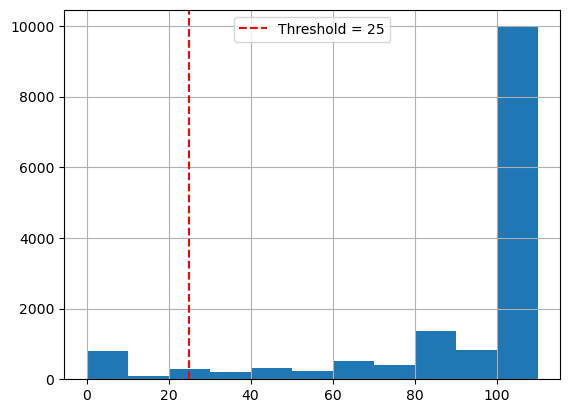

In [20]:
# 4.3

ax = train_df['creditworthiness'].hist(bins=range(0, 111, 10))
ax.axvline(25, color='red', linestyle='--', label='Threshold = 25')
ax.legend()

In [22]:
# 4.4

threshold = 25
train = train_df.copy()
train['outcome'] = np.where(
    train['creditworthiness'] >= threshold, 'Favorable (Approved)', 'Unfavorable (Declined)'
)
train['group'] = np.where(train['AGE'] < 40, 'Privileged (Young)', 'Unprivileged (Old)')
table = pd.crosstab(train['outcome'], train['group'])
# put Unfavorable row first to match FAQ table layout
table = table.reindex(['Unfavorable (Declined)', 'Favorable (Approved)'])
print(table)

group                   Privileged (Young)  Unprivileged (Old)
outcome                                                       
Unfavorable (Declined)                 815                 366
Favorable (Approved)                  9652                4167


Analysis, not much age bias noticed. That’s expected with threshold 25: almost everyone is approved. Disparate Impact would be about (0.919/0.922 ≈ 1.0) (near ideal)

Old has fewer approvals mainly because there are fewer older people in the train set — not because the threshold treats them differently.

Step 5

In [24]:
# 5.1 Fairness metrics on training set (threshold = 25)
# Demographic Parity / Disparate Impact: compare approval rates
# Equal Opportunity: compare TPR among truly good applicants (Y == 0)

threshold = 25
train = train_df.copy()
train['approved'] = train['creditworthiness'] >= threshold
train['privileged'] = train['AGE'] < 40  # young = privileged
y_good = train['default payment next month'] == 0  # Y=0 means no default / "should approve"

priv = train['privileged'] # where 'privileged' is true
unpriv = ~priv # flips it so where 'privileged' is false

# --- Demographic Parity ---
# approval rate = P(approved | group)
ar_priv = train.loc[priv, 'approved'].mean()
ar_unpriv = train.loc[unpriv, 'approved'].mean()
dp_diff = ar_unpriv - ar_priv                    # difference (unprivileged - privileged)
disparate_impact = ar_unpriv / ar_priv            # ratio form (handout example); ideal = 1.0

# --- Equal Opportunity ---
# TPR = P(approved | Y=0, group)  among people who truly deserved approval
tpr_priv = train.loc[priv & y_good, 'approved'].mean()
tpr_unpriv = train.loc[unpriv & y_good, 'approved'].mean()
eo_diff = tpr_unpriv - tpr_priv

print('Demographic Parity')
print(f'  approval rate privileged (young):   {ar_priv:.4f}')
print(f'  approval rate unprivileged (old):   {ar_unpriv:.4f}')
print(f'  difference (unpriv - priv):         {dp_diff:.4f}')
print(f'  Disparate Impact (unpriv/priv):     {disparate_impact:.4f}  (ideal 1.0; fair ~0.8-1.25)')
print()
print('Equal Opportunity')
print(f'  TPR privileged (young | Y=0):       {tpr_priv:.4f}')
print(f'  TPR unprivileged (old | Y=0):       {tpr_unpriv:.4f}')
print(f'  difference (unpriv - priv):         {eo_diff:.4f}  (ideal 0)')


Demographic Parity
  approval rate privileged (young):   0.9221
  approval rate unprivileged (old):   0.9193
  difference (unpriv - priv):         -0.0029
  Disparate Impact (unpriv/priv):     0.9969  (ideal 1.0; fair ~0.8-1.25)

Equal Opportunity
  TPR privileged (young | Y=0):       0.9653
  TPR unprivileged (old | Y=0):       0.9675
  difference (unpriv - priv):         0.0022  (ideal 0)


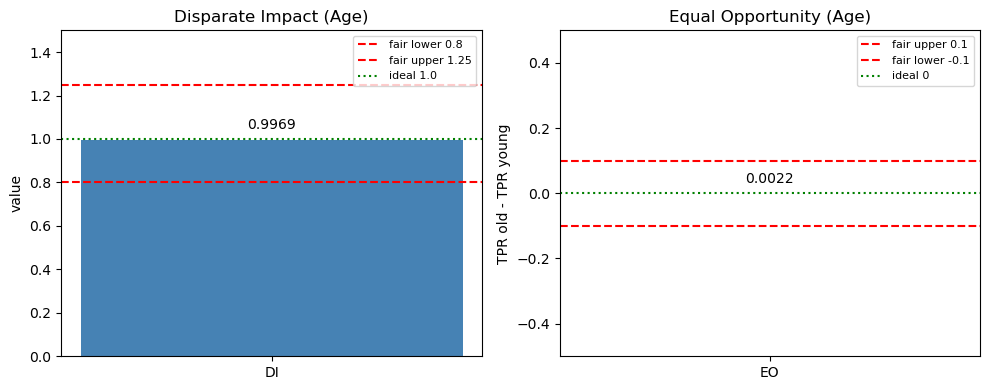

In [28]:
# 5.2 Plot fairness metrics with fair/bias thresholds
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Disparate Impact
axes[0].bar(['DI'], [disparate_impact], color='steelblue')
axes[0].axhline(0.8, color='red', linestyle='--', label='fair lower 0.8')
axes[0].axhline(1.25, color='red', linestyle='--', label='fair upper 1.25')
axes[0].axhline(1.0, color='green', linestyle=':', label='ideal 1.0')
axes[0].set_ylim(0, 1.5)
axes[0].set_title('Disparate Impact (Age)')
axes[0].set_ylabel('value')
axes[0].text(0, disparate_impact + 0.05, round(disparate_impact, 4), ha='center')
axes[0].legend(fontsize=8)

# Equal Opportunity difference
axes[1].bar(['EO'], [eo_diff], color='steelblue')
axes[1].axhline(0.1, color='red', linestyle='--', label='fair upper 0.1')
axes[1].axhline(-0.1, color='red', linestyle='--', label='fair lower -0.1')
axes[1].axhline(0, color='green', linestyle=':', label='ideal 0')
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_title('Equal Opportunity (Age)')
axes[1].set_ylabel('TPR old - TPR young')
axes[1].text(0, eo_diff + 0.03, round(eo_diff, 4), ha='center')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [31]:
# 5.3 Document fairness metrics (simple table for the report)
from IPython.display import display, HTML

summary_5_3 = pd.DataFrame([
    {
        'Fairness metric': 'Disparate Impact',
        'Computed value': round(disparate_impact, 4),
        'Acceptable range': '0.8 to 1.25',
        'Bias?': 'No' if 0.8 <= disparate_impact <= 1.25 else 'Yes',
    },
    {
        'Fairness metric': 'Equal Opportunity',
        'Computed value': round(eo_diff, 4),
        'Acceptable range': '-0.1 to 0.1',
        'Bias?': 'No' if abs(eo_diff) <= 0.1 else 'Yes',
    },
])

display(HTML(summary_5_3.to_html(index=False, border=1)))


Fairness metric,Computed value,Acceptable range,Bias?
Disparate Impact,0.9969,0.8 to 1.25,No
Equal Opportunity,0.0022,-0.1 to 0.1,No


5.4

Based on the two fairness metrics, ther it not much age bias between the privileged group (younger than age 40) and the unprivileged group (age 40 and older) on the training dateset. The Disparate Impact is 0.9969, which is very close to the ideal value of 1.0 and well within the fair range of 0.8 to 1.2, meaning the loan approval rates for young and old applicants were almost the same. Equal Opportunity is 0.0022, which is also near the ideal of 0, so among applicants who did not default, both age groups were approved at nearly the same rate. This result makes sense with our threshold of 25, because most people are approved under that cutoff, so there is little room for one age group to be treated much better or worse than the other. Overall, the metrics do not show bias for or against either the privileged or unprivileged age group at this stage.

Step 6

In [33]:
# 6.1 Starting thresholds: max profit separately for young vs old (training set)

def best_threshold_for_group(group_df, thresholds=range(10, 101, 5)):
    y = group_df['default payment next month']
    score = group_df['creditworthiness']

    def profit_for_threshold(x):
        approve = score >= x
        true_approve = (y == 0)
        p = np.where(true_approve & approve, 10,
            np.where(true_approve & ~approve, -5,
            np.where(~true_approve & approve, -10, 0)))
        return p.sum()

    profits = {x: profit_for_threshold(x) for x in thresholds}
    best_x = max(profits, key=profits.get)
    return best_x, profits[best_x], profits

young_df = train_df[train_df['AGE'] < 40]   # privileged
old_df = train_df[train_df['AGE'] >= 40]    # unprivileged

thresh_young, profit_young, profits_young = best_threshold_for_group(young_df)
thresh_old, profit_old, profits_old = best_threshold_for_group(old_df)

# 6.1 needs two different starting thresholds; if same, nudge one
thresh_priv_start = thresh_young
thresh_unpriv_start = thresh_old
if thresh_priv_start == thresh_unpriv_start:
    thresh_unpriv_start = min(100, thresh_unpriv_start + 5)

# print('Privileged (young): best threshold =', thresh_young, 'profit =', profit_young)
# print('Unprivileged (old): best threshold =', thresh_old, 'profit =', profit_old)
# print()
# print('6.1 starting thresholds:')
print('  privileged (young):', thresh_priv_start)
print('  unprivileged (old):', thresh_unpriv_start)
# print()
# print('young profits:', profits_young)
# print('old profits:', profits_old)


  privileged (young): 25
  unprivileged (old): 10


In [34]:
# 6.2 Optimize thresholds for Disparate Impact (~1.0) and profit
# Metric chosen: Disparate Impact (from Step 5)
# Search different threshold pairs for young vs old on the training set

young = train_df['AGE'] < 40
old = ~young
y_all = train_df['default payment next month']
score_all = train_df['creditworthiness']

def eval_pair(thresh_priv, thresh_unpriv):
    approve = np.where(young, score_all >= thresh_priv, score_all >= thresh_unpriv)
    true_approve = (y_all == 0)
    profit = np.where(true_approve & approve, 10,
                np.where(true_approve & ~approve, -5,
                np.where(~true_approve & approve, -10, 0))).sum()
    ar_priv = approve[young].mean()
    ar_unpriv = approve[old].mean()
    di = ar_unpriv / ar_priv
    return profit, di, ar_priv, ar_unpriv

# try many pairs (not 0); keep pairs with two different thresholds
candidates = []
for tp in range(10, 101, 5):
    for tu in range(10, 101, 5):
        if tp == tu:
            continue  # step 6 uses different thresholds per group
        profit, di, ar_p, ar_u = eval_pair(tp, tu)
        candidates.append({
            'thresh_priv_young': tp,
            'thresh_unpriv_old': tu,
            'profit': int(profit),
            'disparate_impact': di,
            'di_distance': abs(di - 1.0),
            'ar_young': ar_p,
            'ar_old': ar_u,
        })

cand_df = pd.DataFrame(candidates)

# prefer DI in fair range, then closest to 1.0, then highest profit
fair = cand_df[cand_df['disparate_impact'].between(0.8, 1.2)].copy()
fair = fair.sort_values(['di_distance', 'profit'], ascending=[True, False])

best = fair.iloc[0]
thresh_priv = int(best['thresh_priv_young'])
thresh_unpriv = int(best['thresh_unpriv_old'])

print('Metric used: Disparate Impact')
print('6.1 start (25, 10):', eval_pair(25, 10))
print()
print('Top 5 optimized pairs:')
print(fair.head(5).to_string(index=False))
print()
print('Chosen thresholds:')
print('  privileged (young):', thresh_priv)
print('  unprivileged (old):', thresh_unpriv)
print('  profit:', int(best['profit']))
print('  Disparate Impact:', round(best['disparate_impact'], 4))


Metric used: Disparate Impact
6.1 start (25, 10): (86345, 1.0217596857744136, 0.9221362376994363, 0.942201632472976)

Top 5 optimized pairs:
 thresh_priv_young  thresh_unpriv_old  profit  disparate_impact  di_distance  ar_young   ar_old
                35                 40   85600          1.000183     0.000183  0.908283 0.908449
                40                 35   85600          1.000183     0.000183  0.908283 0.908449
                15                 10   86160          1.000408     0.000408  0.941817 0.942202
                20                 10   86160          1.000408     0.000408  0.941817 0.942202
                95                100   62385          1.001847     0.001847  0.663896 0.665122

Chosen thresholds:
  privileged (young): 35
  unprivileged (old): 40
  profit: 85600
  Disparate Impact: 1.0002


Answer:

We updated the threshold from 25 for both groups to 35 for the privileged (young) group and 40 for the unprivileged (old) group and while we were able to achieve much better Disparate Impact score of 1.000183 from 0.9969, our profit did drop from 86335 to 85600 which is less than 1% change and this is expected because we are using 2 different thrsholds to improve fairness rather than only maximizing profit with one shared threshold.

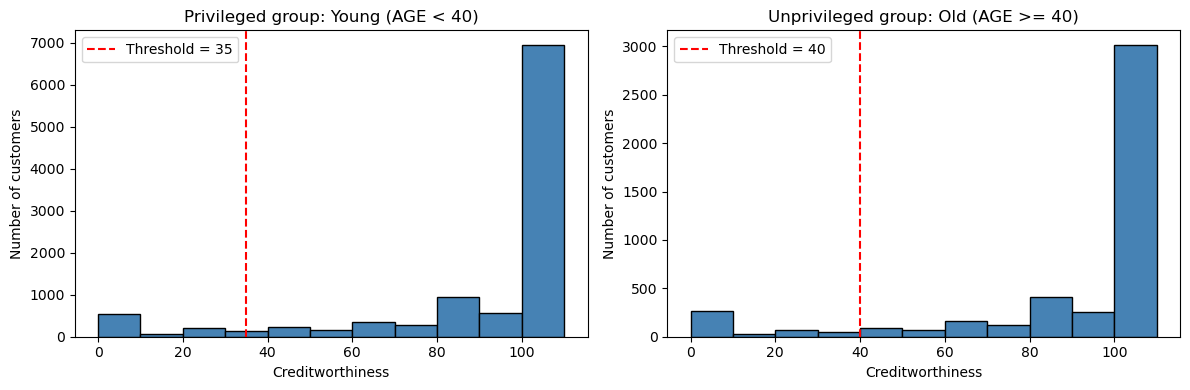

In [35]:
# 6.3 Histograms by age group with group-specific thresholds
import matplotlib.pyplot as plt

thresh_priv = 35      # young
thresh_unpriv = 40    # old

young_scores = train_df.loc[train_df['AGE'] < 40, 'creditworthiness']
old_scores = train_df.loc[train_df['AGE'] >= 40, 'creditworthiness']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Privileged (young)
axes[0].hist(young_scores, bins=range(0, 111, 10), color='steelblue', edgecolor='black')
axes[0].axvline(thresh_priv, color='red', linestyle='--', label=f'Threshold = {thresh_priv}')
axes[0].set_title('Privileged group: Young (AGE < 40)')
axes[0].set_xlabel('Creditworthiness')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Unprivileged (old)
axes[1].hist(old_scores, bins=range(0, 111, 10), color='steelblue', edgecolor='black')
axes[1].axvline(thresh_unpriv, color='red', linestyle='--', label=f'Threshold = {thresh_unpriv}')
axes[1].set_title('Unprivileged group: Old (AGE >= 40)')
axes[1].set_xlabel('Creditworthiness')
axes[1].set_ylabel('Number of customers')
axes[1].legend()

plt.tight_layout()
plt.show()


6.4
1. The threshold for the priviledged group is 35, while the unprivileged group is 40.
2. The profit is 85600

In [36]:
# 6.5 Favorable vs Unfavorable by group (new thresholds)
from IPython.display import display, HTML

thresh_priv = 35    # young
thresh_unpriv = 40  # old

train = train_df.copy()
train['group'] = np.where(train['AGE'] < 40, 'Privileged (Young)', 'Unprivileged (Old)')
train['outcome'] = np.where(
    ((train['AGE'] < 40) & (train['creditworthiness'] >= thresh_priv)) |
    ((train['AGE'] >= 40) & (train['creditworthiness'] >= thresh_unpriv)),
    'Favorable (Approved)',
    'Unfavorable (Declined)'
)

table_6_5 = pd.crosstab(train['outcome'], train['group'])
table_6_5 = table_6_5.reindex(['Unfavorable (Declined)', 'Favorable (Approved)'])
display(HTML(table_6_5.to_html(border=1)))



group,Privileged (Young),Unprivileged (Old)
outcome,,
Unfavorable (Declined),960,415
Favorable (Approved),9507,4118


Step 7

    For both fairness metrics in Step 5, the privileged (young) and unprivileged (old) groups had almost the same outcomes. Disparate Impact from Demographic Parity is 0.9969, so the approval rates were nearly equal with about 92.2% for young and 91.9% for old group. Equal Opportunity was also very close, the True Positive Rate difference was only about 0.0022, meaning that among the people who did not default (Y = 0), both age groups were approved at almost the same rate. Overall, Step 5 did not show a big difference in outcomes between the privileged and unprivileged groups.

    The Step 6 mitigation showed slight improvement, and mainly for fairness on Disparate Impact. By using different thresholds of 35 for young and 40 for old group, Disparate Impact improved from 0.9969 to 1.0002, and the approval rates became even closer with both groups being around 90.8%. Because there was ony a little bias to begin with, neither group gained a large advantage. Both groups were approved a bit less often than under the single threshold of 25, and total profit dropped from 86335 to 85600. So the mitigation made the groups more equal, but it also made approval stricter for both, with a small tradeoff in profit.

    One issue with this method is that using different thresholds by age can itself look unfair or even illegal under credit rules like ECOA, because age is a protected class and the bank would be applying different thresholds on purpose resulting in age bias. Another issue is that Disparate Impact only matches approval rates, it does not guarantee better decisions for people who are truly good or bad credit risks. Also, raising thresholds to make rates match can reduce overall approvals and profit even when bias was already small, increasing Disparate Impact may not be worth the tradeoff. Finally, the result depends on how groups and thresholds are chosen, so the method may not work the same way on new data

References

5.3
- https://www.eeoc.gov/laws/guidance/questions-and-answers-clarify-and-provide-common-interpretation-uniform-guidelines
- https://link.springer.com/article/10.1007/s43681-024-00541-3